# Bangla Rumour Detection — BanglaBERT

## Dataset Splits
| Split | Rumour | Non-Rumour | Total |
|---|---|---|---|
| Train | 3,998 | 4,200 | 8,198 |
| Val | 700 | 700 | 1,400 |
| Test | 700 | 700 | 1,400 |

Linguistic marker validation is computed live in Cell 5 from the actual data — no hardcoded numbers here.

In [1]:
# ── CELL 1: Install ──────────────────────────────────────────────
!pip install -q pyspark transformers torch scikit-learn pandas \
               openpyxl numpy matplotlib seaborn scipy datasets

In [7]:
# ── CELL 2: Config & Imports ─────────────────────────────────────
import re, os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report, confusion_matrix
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW

# ── Paths — update these to your file locations ──────────────────
# Use the new balanced files generated from the preprocessing step
TRAIN_R_PATH  = 'train_rumour_new.xlsx'
TRAIN_NR_PATH = 'train_non_rumour_new.xlsx'
VAL_R_PATH    = '/content/val_rumour_700.xlsx'
VAL_NR_PATH   = 'val_non_rumour_700.xlsx'
TEST_R_PATH   = 'test_rumour_balanced.xlsx'
TEST_NR_PATH  = 'test_non_rumour_balanced.xlsx'

# ── Model config ─────────────────────────────────────────────────
MODEL_NAME  = 'csebuetnlp/banglabert'
MAX_LEN     = 128
BATCH_SIZE  = 16
EPOCHS      = 4
LR          = 2e-5
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [8]:
# ── CELL 3: PySpark Preprocessing ───────────────────────────────
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName('BanglaRumour')
    .config('spark.driver.memory', '4g')
    .config('spark.sql.shuffle.partitions', '8')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')

TAXONOMY = ['cultural','political','sports','religious','health','celebrity','international']

def load_and_clean(path, label_val):
    pdf = pd.read_excel(path)
    cols_to_keep = ['text']
    if 'description' in pdf.columns:
        cols_to_keep.append('description')
    for c in TAXONOMY:
        if c in pdf.columns:
            cols_to_keep.append(c)
    # 'label' is intentionally excluded from cols_to_keep.
    # Raw val files have INVERTED labels (val_rumour=0, val_non_rumour=1).
    # Always override with label_val — never trust the file's label column.
    pdf = pdf[cols_to_keep].copy()
    pdf['label'] = label_val  # correct label always set here
    pdf['text']  = pdf['text'].fillna('').astype(str).str.strip()
    if 'description' not in pdf.columns:
        pdf['description'] = ''
    else:
        pdf['description'] = pdf['description'].fillna('').astype(str)
    sdf = spark.createDataFrame(pdf)
    n0  = sdf.count()
    sdf = sdf.filter(F.length('text') >= 5)
    sdf = sdf.filter(~F.col('text').isin('nan','None',''))
    sdf = sdf.withColumn('text', F.trim(F.regexp_replace('text', r'\s+', ' ')))
    sdf = sdf.dropDuplicates(['text'])
    print(f"  {path.split('/')[-1]:40s}: {n0:,} -> {sdf.count():,} rows")
    return sdf.toPandas()

print('Loading & cleaning splits...')
df_train_r  = load_and_clean(TRAIN_R_PATH,  1)
df_train_nr = load_and_clean(TRAIN_NR_PATH, 0)
df_val_r    = load_and_clean(VAL_R_PATH,    1)
df_val_nr   = load_and_clean(VAL_NR_PATH,   0)
df_test_r   = load_and_clean(TEST_R_PATH,   1)
df_test_nr  = load_and_clean(TEST_NR_PATH,  0)

df_train = pd.concat([df_train_r, df_train_nr], ignore_index=True)
df_val   = pd.concat([df_val_r,   df_val_nr],   ignore_index=True)
df_test  = pd.concat([df_test_r,  df_test_nr],  ignore_index=True)

print('\nCross-contamination checks (rows removed):')

# 1. Remove val/test texts that appear in train
train_texts = set(df_train['text'])
val_in_train  = df_val['text'].isin(train_texts).sum()
test_in_train = df_test['text'].isin(train_texts).sum()
df_val  = df_val[~df_val['text'].isin(train_texts)].reset_index(drop=True)
df_test = df_test[~df_test['text'].isin(train_texts)].reset_index(drop=True)
print(f'  Val  rows found in train  → removed: {val_in_train}')
print(f'  Test rows found in train  → removed: {test_in_train}')

# 2. Remove val <-> test cross-contamination
val_texts  = set(df_val['text'])
test_texts = set(df_test['text'])
test_in_val = df_test['text'].isin(val_texts).sum()
val_in_test = df_val['text'].isin(test_texts).sum()
df_test = df_test[~df_test['text'].isin(val_texts)].reset_index(drop=True)
df_val  = df_val[~df_val['text'].isin(set(df_test['text']))].reset_index(drop=True)
print(f'  Test rows found in val    → removed: {test_in_val}')
print(f'  Val  rows found in test   → removed: {val_in_test}')

print('\nFinal sizes after all contamination checks:')
for name, df in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    r  = (df['label']==1).sum()
    nr = (df['label']==0).sum()
    print(f'  {name}: {len(df):,} total | Rumour={r:,} | NonRumour={nr:,}')


Loading & cleaning splits...
  train_rumour_new.xlsx                   : 3,998 -> 3,997 rows
  train_non_rumour_new.xlsx               : 4,200 -> 4,200 rows
  val_rumour_700.xlsx                     : 700 -> 700 rows
  val_non_rumour_700.xlsx                 : 700 -> 700 rows
  test_rumour_balanced.xlsx               : 700 -> 700 rows
  test_non_rumour_balanced.xlsx           : 700 -> 700 rows

Cross-contamination checks (rows removed):
  Val  rows found in train  → removed: 0
  Test rows found in train  → removed: 0
  Test rows found in val    → removed: 0
  Val  rows found in test   → removed: 0

Final sizes after all contamination checks:
  TRAIN: 8,197 total | Rumour=3,997 | NonRumour=4,200
  VAL: 1,400 total | Rumour=700 | NonRumour=700
  TEST: 1,400 total | Rumour=700 | NonRumour=700


In [ ]:
# ── CELL 4: Linguistic Marker Extraction (20 validated markers) ──
# All 20 passed: p<0.05 AND >1% absolute difference between classes
# Tested on full combined dataset before model training
import re

MARKER_PATTERNS = {

    # ── Structural ───────────────────────────────────────────────
    'text_length':   lambda row: len(row['text']),
    'word_count':    lambda row: len(row['text'].split()),
    'short_title':   lambda row: int(len(row['text'].split()) < 5),
    'long_title':    lambda row: int(len(row['text'].split()) > 12),
    'ends_question': lambda row: int(row['text'].strip().endswith('?')),

    # ── Lexical ──────────────────────────────────────────────────
    'claim_verb': lambda row: int(bool(re.search(
        r'দাবি|দাবি করা হয়েছে|বলা হচ্ছে|দাবি করেছে|দাবি করা হচ্ছে',
        row['text']))),

    'negation_words': lambda row: int(bool(re.search(
        r'না |নয়|নেই|নাই|অস্বীকার|মিথ্যা|ভুল|অসত্য',
        row['text']))),

    'clickbait': lambda row: int(bool(re.search(
        r'চাঞ্চল্যকর|হতবাক|অবিশ্বাস্য|অবাক|বিস্ময়কর|ভাইরাল|সবাই জানুন|শকিং',
        row['text']))),



    # ── Attribution ──────────────────────────────────────────────
    'has_quote': lambda row: int(bool(re.search(
        r'বলেন|জানান|মন্তব্য করেন|বলেছেন|জানিয়েছেন|উল্লেখ করেন|দাবি করেন',
        row['text']))),

    'unnamed_source': lambda row: int(bool(re.search(
        r'সূত্র জানায়|সূত্র মতে|নাম প্রকাশে অনিচ্ছুক|বিশ্বস্ত সূত্র|বিশেষ সূত্র',
        row['text'] + ' ' + row['description']))),

    'named_outlet': lambda row: int(bool(re.search(
        r'প্রথম আলো|Daily Star|বিডিনিউজ|কালের কণ্ঠ|যুগান্তর|সমকাল|ইত্তেফাক|মানবজমিন|বাংলাদেশ প্রতিদিন',
        row['text']))),

    # ── Content / Topic ──────────────────────────────────────────
    'has_numbers':    lambda row: int(bool(re.search(r'\d+', row['text']))),


    'religious_alarm': lambda row: int(bool(re.search(
        r'আল্লাহ|ইসলাম|হারাম|কোরআন|হাদিস|ফতোয়া|পাপ|পুণ্য|জিহাদ',
        row['text']))),

    'health_claim': lambda row: int(bool(re.search(
        r'ক্যান্সার|ভ্যাকসিন|ওষুধ|চিকিৎসা|রোগ নিরাময়|ভাইরাস|করোনা|ডেঙ্গু',
        row['text']))),

}

VALID_MARKERS = list(MARKER_PATTERNS.keys())
print(f'Extracting {len(VALID_MARKERS)} validated markers...')

def add_markers(df):
    df = df.copy()
    df['description'] = df['description'].fillna('').astype(str)
    for name, fn in MARKER_PATTERNS.items():
        df[name] = df.apply(fn, axis=1)
    return df

df_train = add_markers(df_train)
df_val   = add_markers(df_val)
df_test  = add_markers(df_test)
print(f'Done. {len(VALID_MARKERS)} markers added to all splits.')


Marker                     Rumour  NonRumour         Stat    p-value    Verdict
──────────────────────────────────────────────────────────────────────────────
text_length                 65.81      49.56   U=22563737     0.0000    ✅ VALID
word_count                   9.83       7.30   U=23117884     0.0000    ✅ VALID
short_title                  1.2%       7.1%     χ²=237.0     0.0000    ✅ VALID
long_title                  17.3%       0.9%     χ²=907.9     0.0000    ✅ VALID
ends_question                1.0%       3.8%      χ²=86.0     0.0000    ✅ VALID
claim_verb                  28.5%       1.6%    χ²=1582.0     0.0000    ✅ VALID
negation_words              16.0%      10.0%      χ²=87.6     0.0000    ✅ VALID
clickbait                    1.4%       0.2%      χ²=50.9     0.0000    ✅ VALID
has_quote                    5.4%       0.1%     χ²=287.9     0.0000    ✅ VALID
unnamed_source               1.8%       0.2%      χ²=64.4     0.0000    ✅ VALID
named_outlet                 2.8%       0

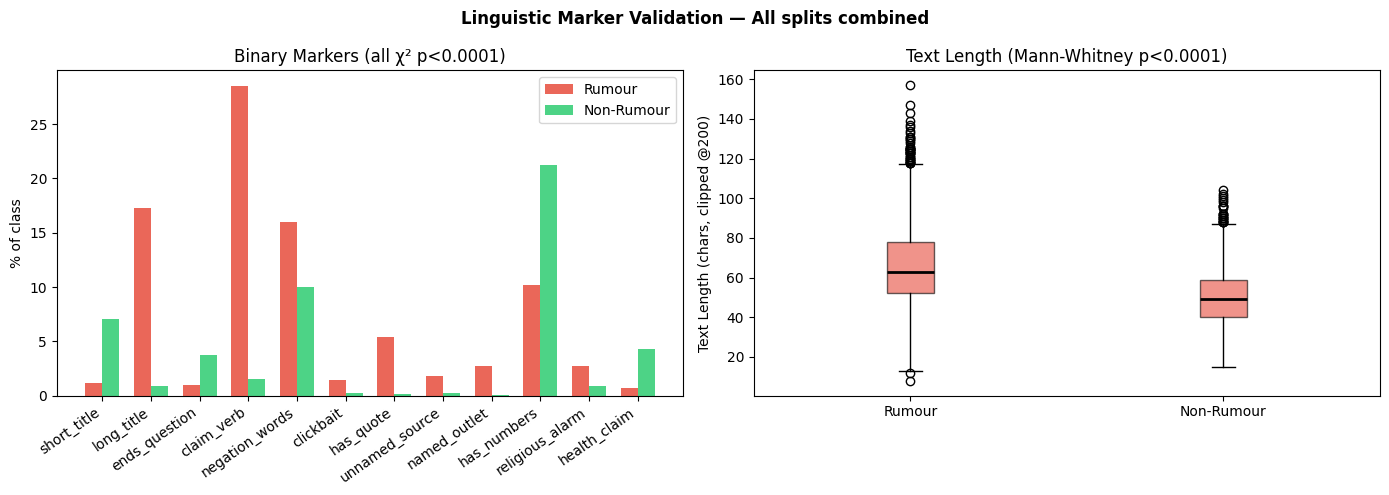

Figure saved: linguistic_markers.png


In [23]:
# ── CELL 5: Marker Validation Report & Plot ──────────────────────
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
r_all  = df_all[df_all['label']==1]
nr_all = df_all[df_all['label']==0]
print(f'{'Marker':<22} {'Rumour':>10} {'NonRumour':>10} {'Stat':>12} {'p-value':>10} {'Verdict':>10}')
print('─'*78)
rows = []
for m in VALID_MARKERS:
    rv, nrv = r_all[m], nr_all[m]
    if rv.nunique() <= 2:
        ct = [[(rv==1).sum(),(rv==0).sum()],[(nrv==1).sum(),(nrv==0).sum()]]
        chi2, p, _, _ = chi2_contingency(ct)
        r_val, nr_val = f'{(rv==1).mean()*100:.1f}%', f'{(nrv==1).mean()*100:.1f}%'
        stat = f'χ²={chi2:.1f}'
    else:
        stat_val, p = mannwhitneyu(rv, nrv, alternative='two-sided')
        r_val, nr_val = f'{rv.mean():.2f}', f'{nrv.mean():.2f}'
        stat = f'U={stat_val:.0f}'
    rows.append({'marker':m,'rumour':r_val,'non_rumour':nr_val,'stat':stat,'p':p})
    print(f'{m:<22} {r_val:>10} {nr_val:>10} {stat:>12} {p:>10.4f} {"✅ VALID":>10}')

# Visualise binary markers
binary_markers = [m for m in VALID_MARKERS if df_all[m].nunique()<=2]
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Linguistic Marker Validation — All splits combined', fontweight='bold')

r_means  = [r_all[m].mean()*100  for m in binary_markers]
nr_means = [nr_all[m].mean()*100 for m in binary_markers]
x = np.arange(len(binary_markers)); w=0.35
axes[0].bar(x-w/2, r_means,  w, label='Rumour',     color='#e74c3c', alpha=0.85)
axes[0].bar(x+w/2, nr_means, w, label='Non-Rumour', color='#2ecc71', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(binary_markers, rotation=35, ha='right')
axes[0].set_ylabel('% of class'); axes[0].legend()
axes[0].set_title('Binary Markers (all χ² p<0.0001)')

# Text length distribution
axes[1].boxplot([r_all['text_length'].clip(upper=200), nr_all['text_length'].clip(upper=200)],
    labels=['Rumour','Non-Rumour'], patch_artist=True,
    boxprops=dict(facecolor='#e74c3c', alpha=0.6),
    medianprops=dict(color='black', linewidth=2))
axes[1].set_ylabel('Text Length (chars, clipped @200)')
axes[1].set_title('Text Length (Mann-Whitney p<0.0001)')
plt.tight_layout()
plt.savefig('linguistic_markers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: linguistic_markers.png')

In [24]:
# ── CELL 6: Install Traditional Model Dependencies ───────────────
!pip install -q xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import hstack, csr_matrix
import xgboost as xgb
print('Traditional model imports done.')

Traditional model imports done.


In [26]:
# ── CELL 7: Feature Construction ─────────────────────────────────
# Two feature spaces used across five models:
#
#   TFIDF    — char (2-5) + word (1-3) n-gram TF-IDF on raw text
#              captures surface patterns and Bangla morphology
#   MARKERS  — the validated linguistic markers as a numeric matrix
#
# Models 1-3 use TF-IDF only  → tests surface patterns
# Model  4   uses TF-IDF + Markers → tests if markers add signal
# Model  5   uses TF-IDF + Markers with XGBoost → strongest traditional upper bound
# ─────────────────────────────────────────────────────────────────

# Fit on train only — transform val/test separately (no leakage)
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_char = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(2, 5),
    max_features=80_000, sublinear_tf=True
)
tfidf_word = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 3),
    max_features=80_000, sublinear_tf=True
)

X_train_char = tfidf_char.fit_transform(df_train['text'])
X_val_char   = tfidf_char.transform(df_val['text'])
X_test_char  = tfidf_char.transform(df_test['text'])

X_train_word = tfidf_word.fit_transform(df_train['text'])
X_val_word   = tfidf_word.transform(df_val['text'])
X_test_word  = tfidf_word.transform(df_test['text'])

# Combined TF-IDF (char + word columns side by side)
X_train_tfidf = hstack([X_train_char, X_train_word])
X_val_tfidf   = hstack([X_val_char,   X_val_word])
X_test_tfidf  = hstack([X_test_char,  X_test_word])

# Linguistic marker matrices
X_train_markers = csr_matrix(df_train[VALID_MARKERS].values.astype(float))
X_val_markers   = csr_matrix(df_val[VALID_MARKERS].values.astype(float))
X_test_markers  = csr_matrix(df_test[VALID_MARKERS].values.astype(float))

# Combined: TF-IDF + Markers (for Models 4 & 5)
X_train_combined = hstack([X_train_tfidf, X_train_markers])
X_val_combined   = hstack([X_val_tfidf,   X_val_markers])
X_test_combined  = hstack([X_test_tfidf,  X_test_markers])

y_train = df_train['label'].values
y_val   = df_val['label'].values
y_test  = df_test['label'].values

print(f'TF-IDF features  : {X_train_tfidf.shape[1]:,}')
print(f'Marker features  : {X_train_markers.shape[1]}')
print(f'Combined features: {X_train_combined.shape[1]:,}')
print(f'Train={len(y_train):,} | Val={len(y_val):,} | Test={len(y_test):,}')

TF-IDF features  : 129,199
Marker features  : 14
Combined features: 129,213
Train=8,197 | Val=1,400 | Test=1,400


In [27]:
# ── CELL 8: Train All Five Traditional Models ────────────────────
# Val set is used only for C selection in LR and SVM (grid search).
# RF and XGBoost use robust fixed defaults — grid search over 160K+
# features is computationally prohibitive and unlikely to change results.
# ALL final metrics are computed on the external test set only.
# ─────────────────────────────────────────────────────────────────

SEED = 42
results = {}   # {model_name: {'val': metrics_dict, 'test': metrics_dict}}

def compute_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'Precision':   round(precision_score(y_true, y_pred, average='macro'), 4),
        'Recall':      round(recall_score(y_true, y_pred, average='macro'), 4),
        'Macro-F1':    round(f1_score(y_true, y_pred, average='macro'), 4),
        'Weighted-F1': round(f1_score(y_true, y_pred, average='weighted'), 4),
        'ROC-AUC':     round(roc_auc_score(y_true, y_prob), 4),
    }

def fit_and_store(name, clf, X_tr, X_vl, X_te, proba=True):
    """Fit clf, evaluate on val+test, store in results."""
    clf.fit(X_tr, y_train)
    vp = clf.predict(X_vl)
    tp = clf.predict(X_te)
    vprob = clf.predict_proba(X_vl)[:,1] if proba else clf.decision_function(X_vl)
    tprob = clf.predict_proba(X_te)[:,1] if proba else clf.decision_function(X_te)
    results[name] = {
        'val':  compute_metrics(y_val,  vp, vprob),
        'test': compute_metrics(y_test, tp, tprob),
        'val_pred':  vp,  'val_prob':  vprob,
        'test_pred': tp,  'test_prob': tprob,
    }
    print(f'  Val  Macro-F1={results[name]["val"]["Macro-F1"]:.4f} | '
          f'Test Macro-F1={results[name]["test"]["Macro-F1"]:.4f}')

# ── MODEL 1: Logistic Regression + TF-IDF ────────────────────────
# Rationale: Simplest linear baseline. Gap to BanglaBERT quantifies
# the value of contextual understanding over word frequency alone.
print('\n' + '='*60)
print('MODEL 1: Logistic Regression + TF-IDF')
print('='*60)
best_c, best_f1 = None, -1
for C in [0.01, 0.1, 1.0, 10.0]:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=SEED,
                            class_weight='balanced', solver='saga')
    lr.fit(X_train_tfidf, y_train)
    vf1 = f1_score(y_val, lr.predict(X_val_tfidf), average='macro')
    print(f'  C={C:<6} Val Macro-F1={vf1:.4f}')
    if vf1 > best_f1:
        best_f1, best_c = vf1, C
print(f'  → Best C={best_c}')
lr_best = LogisticRegression(C=best_c, max_iter=1000, random_state=SEED,
                             class_weight='balanced', solver='saga')
fit_and_store('Logistic Regression', lr_best, X_train_tfidf, X_val_tfidf, X_test_tfidf)

# ── MODEL 2: SVM (LinearSVC) + TF-IDF ────────────────────────────
# Rationale: Pre-BERT SOTA for text classification. Max-margin
# classifier handles high-dimensional sparse TF-IDF better than LR.
# CalibratedClassifierCV adds Platt scaling for probability output.
print('\n' + '='*60)
print('MODEL 2: SVM (LinearSVC) + TF-IDF')
print('='*60)
best_c_svm, best_f1_svm = None, -1
for C in [0.01, 0.1, 1.0, 10.0]:
    svm = CalibratedClassifierCV(
        LinearSVC(C=C, max_iter=2000, random_state=SEED, class_weight='balanced'), cv=3)
    svm.fit(X_train_tfidf, y_train)
    vf1 = f1_score(y_val, svm.predict(X_val_tfidf), average='macro')
    print(f'  C={C:<6} Val Macro-F1={vf1:.4f}')
    if vf1 > best_f1_svm:
        best_f1_svm, best_c_svm = vf1, C
print(f'  → Best C={best_c_svm}')
svm_best = CalibratedClassifierCV(
    LinearSVC(C=best_c_svm, max_iter=2000, random_state=SEED, class_weight='balanced'), cv=3)
fit_and_store('SVM (LinearSVC)', svm_best, X_train_tfidf, X_val_tfidf, X_test_tfidf)

# ── MODEL 3: XGBoost + TF-IDF ────────────────────────────────────
# Rationale: Strongest traditional model on raw text. Non-linear
# gradient boosting captures feature interactions that LR and SVM miss.
# Direct fair comparison to LR and SVM on the same feature set.
print('\n' + '='*60)
print('MODEL 3: XGBoost + TF-IDF')
print('='*60)
scale_pos = float((y_train == 0).sum()) / float((y_train == 1).sum())
xgb_tfidf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss', random_state=SEED, n_jobs=-1,
    tree_method='hist'   # fast on sparse matrices
)
fit_and_store('XGBoost + TF-IDF', xgb_tfidf, X_train_tfidf, X_val_tfidf, X_test_tfidf)

# ── MODEL 4: Random Forest + TF-IDF + Markers ────────────────────
# Rationale: Tests whether our validated linguistic markers add
# discriminative signal ON TOP of TF-IDF. Feature importance plot
# empirically ranks which markers matter most — publishable finding.
print('\n' + '='*60)
print('MODEL 4: Random Forest + TF-IDF + Markers')
print('='*60)
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
fit_and_store('Random Forest + TF-IDF + Markers', rf,
              X_train_combined, X_val_combined, X_test_combined)

# ── MODEL 5: XGBoost + TF-IDF + Markers ──────────────────────────
# Rationale: Strongest traditional model with ALL available features.
# Upper bound of what traditional ML can achieve on this task.
# Gap between this and BanglaBERT = case for deep contextual learning.
print('\n' + '='*60)
print('MODEL 5: XGBoost + TF-IDF + Markers')
print('='*60)
xgb_combined = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss', random_state=SEED, n_jobs=-1,
    tree_method='hist'
)
fit_and_store('XGBoost + TF-IDF + Markers', xgb_combined,
              X_train_combined, X_val_combined, X_test_combined)

print('\n✅ All five models trained and evaluated.')


MODEL 1: Logistic Regression + TF-IDF
  C=0.01   Val Macro-F1=0.9657
  C=0.1    Val Macro-F1=0.9714
  C=1.0    Val Macro-F1=0.9757
  C=10.0   Val Macro-F1=0.9764
  → Best C=10.0
  Val  Macro-F1=0.9764 | Test Macro-F1=0.9693

MODEL 2: SVM (LinearSVC) + TF-IDF
  C=0.01   Val Macro-F1=0.9671
  C=0.1    Val Macro-F1=0.9729
  C=1.0    Val Macro-F1=0.9729
  C=10.0   Val Macro-F1=0.9714
  → Best C=0.1
  Val  Macro-F1=0.9729 | Test Macro-F1=0.9643

MODEL 3: XGBoost + TF-IDF
  Val  Macro-F1=0.9757 | Test Macro-F1=0.9693

MODEL 4: Random Forest + TF-IDF + Markers
  Val  Macro-F1=0.9800 | Test Macro-F1=0.9750

MODEL 5: XGBoost + TF-IDF + Markers
  Val  Macro-F1=0.9736 | Test Macro-F1=0.9636

✅ All five models trained and evaluated.


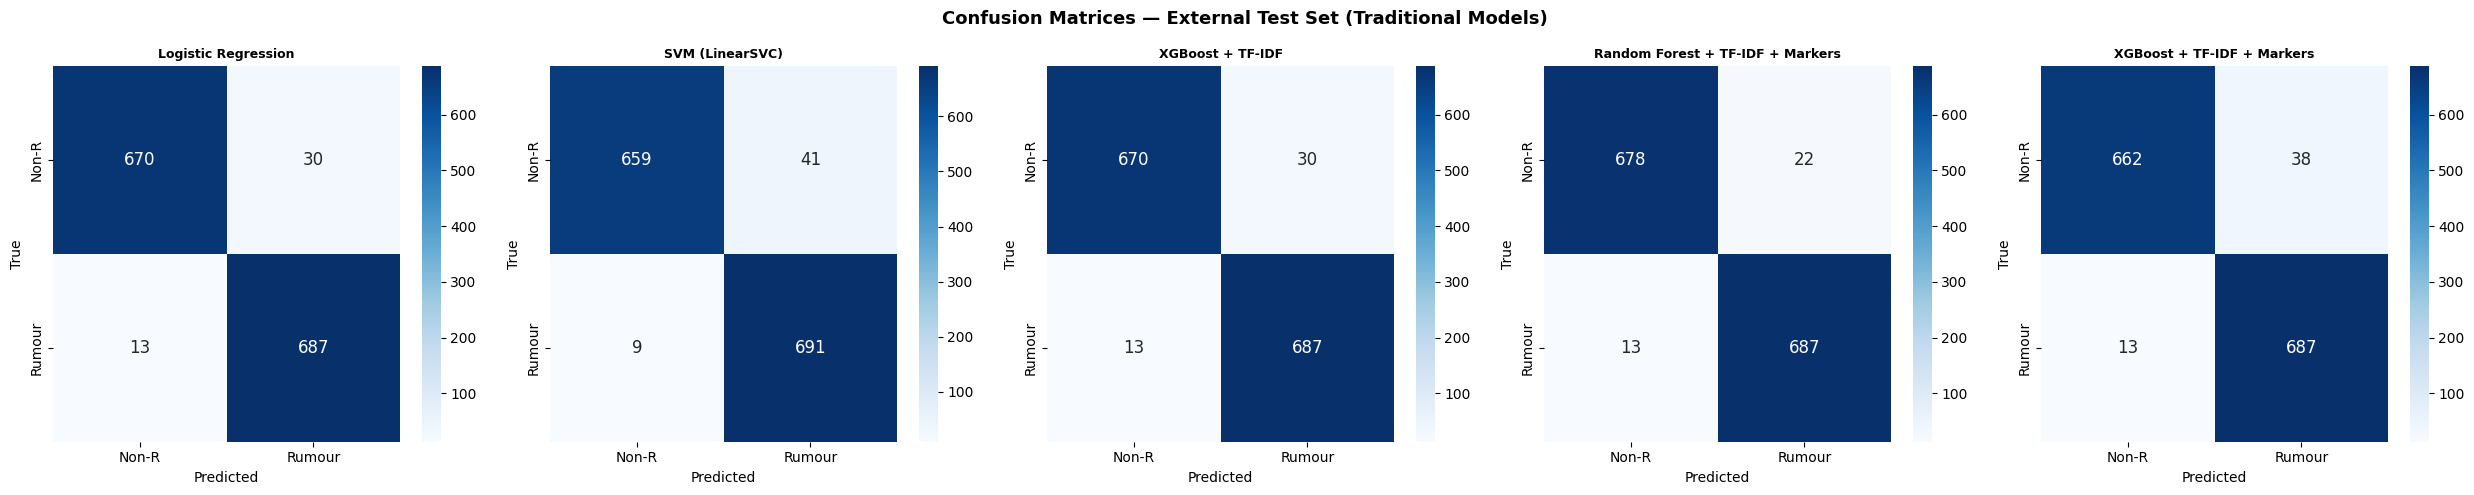

Figure saved: confusion_matrices_traditional.png


In [28]:
# ── CELL 9: Confusion Matrices — External Test Set ───────────────
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Confusion Matrices — External Test Set (Traditional Models)',
             fontweight='bold', fontsize=13)

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['test_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=['Non-R', 'Rumour'],
                yticklabels=['Non-R', 'Rumour'],
                cmap='Blues', annot_kws={'size': 12})
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices_traditional.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: confusion_matrices_traditional.png')

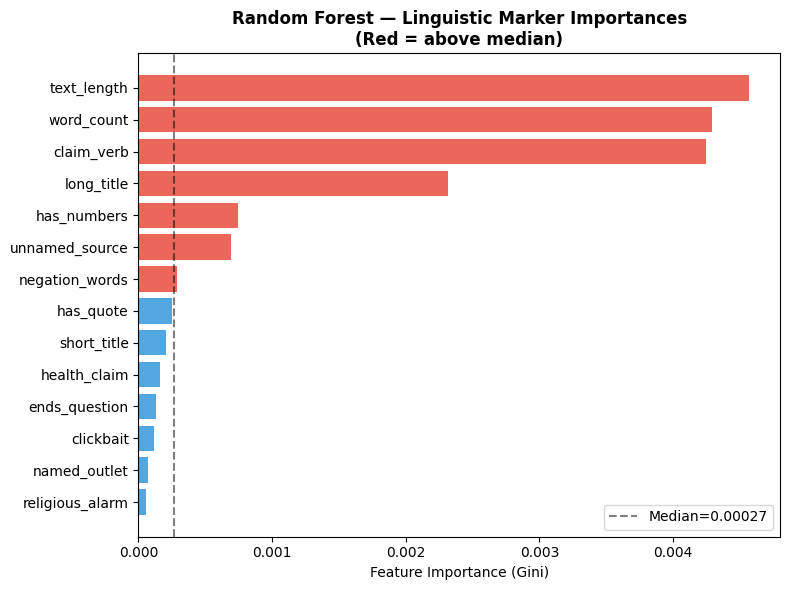

Figure saved: marker_importance.png

Marker importances (ranked):
         Marker  Importance
    text_length    0.004572
     word_count    0.004291
     claim_verb    0.004247
     long_title    0.002319
    has_numbers    0.000747
 unnamed_source    0.000692
 negation_words    0.000285
      has_quote    0.000249
    short_title    0.000207
   health_claim    0.000158
  ends_question    0.000135
      clickbait    0.000114
   named_outlet    0.000075
religious_alarm    0.000057


In [29]:
# ── CELL 10: Random Forest — Linguistic Marker Feature Importance ─
# The combined feature matrix = [TF-IDF cols | marker cols].
# Extract importance for the marker columns only (last N columns).
# This is the empirical validation of our marker selection — shows
# WHICH markers the model found most discriminative.
# ─────────────────────────────────────────────────────────────────
n_tfidf   = X_train_tfidf.shape[1]
fi        = rf.feature_importances_
marker_fi = fi[n_tfidf:]     # last len(VALID_MARKERS) columns

fi_df = pd.DataFrame({
    'Marker':     VALID_MARKERS,
    'Importance': marker_fi
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
median_fi = fi_df['Importance'].median()
colors = ['#e74c3c' if v >= median_fi else '#3498db' for v in fi_df['Importance']]
ax.barh(fi_df['Marker'], fi_df['Importance'], color=colors, alpha=0.85)
ax.axvline(median_fi, color='black', linestyle='--', alpha=0.5, label=f'Median={median_fi:.5f}')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Linguistic Marker Importances\n(Red = above median)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('marker_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: marker_importance.png')
print()
print('Marker importances (ranked):')
print(fi_df.sort_values('Importance', ascending=False).to_string(index=False))


TRADITIONAL MODELS — FINAL RESULTS (External Val & Test Sets)

── Validation Set (External) ──
                                  Accuracy  Precision  Recall  Macro-F1  Weighted-F1  ROC-AUC
Model                                                                                        
Logistic Regression                 0.9764     0.9765  0.9764    0.9764       0.9764   0.9974
SVM (LinearSVC)                     0.9729     0.9732  0.9729    0.9729       0.9729   0.9973
XGBoost + TF-IDF                    0.9757     0.9757  0.9757    0.9757       0.9757   0.9945
Random Forest + TF-IDF + Markers    0.9800     0.9801  0.9800    0.9800       0.9800   0.9981
XGBoost + TF-IDF + Markers          0.9736     0.9736  0.9736    0.9736       0.9736   0.9941

── Test Set (External) ──
                                  Accuracy  Precision  Recall  Macro-F1  Weighted-F1  ROC-AUC
Model                                                                                        
Logistic Regression            

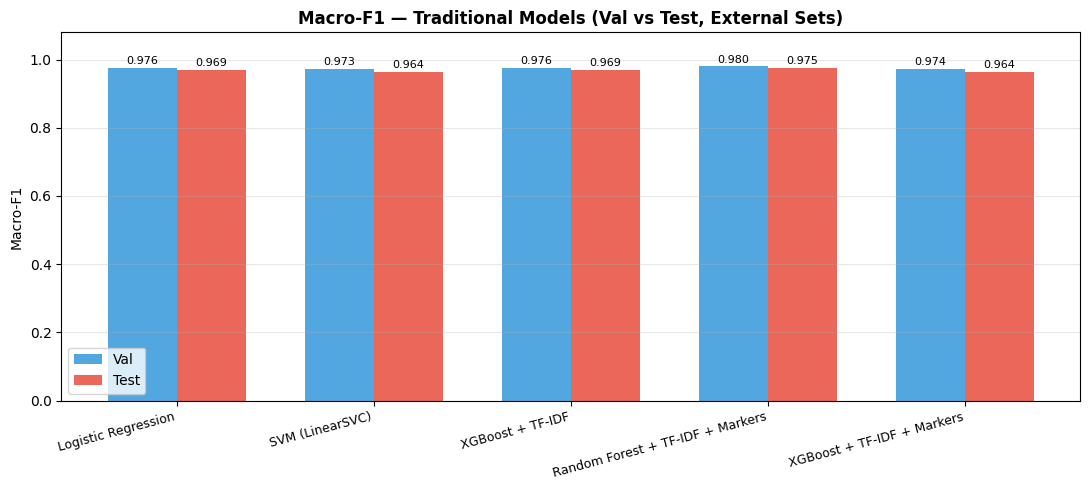

Figure saved: model_comparison_traditional.png
Results saved: traditional_model_results.xlsx


In [30]:
# ── CELL 11: Final Results — All Models ──────────────────────────
# Complete summary table: val + test for all five models.
# Primary metric: Macro-F1 (equal weight to both classes).
# ─────────────────────────────────────────────────────────────────

print('\n' + '='*80)
print('TRADITIONAL MODELS — FINAL RESULTS (External Val & Test Sets)')
print('='*80)

metrics_cols = ['Accuracy','Precision','Recall','Macro-F1','Weighted-F1','ROC-AUC']

val_rows, test_rows = [], []
for name, res in results.items():
    val_rows.append( {'Model': name, **res['val']})
    test_rows.append({'Model': name, **res['test']})

val_df  = pd.DataFrame(val_rows).set_index('Model')
test_df = pd.DataFrame(test_rows).set_index('Model')

print('\n── Validation Set (External) ──')
print(val_df[metrics_cols].to_string())

print('\n── Test Set (External) ──')
print(test_df[metrics_cols].to_string())

# ── Bar chart: Macro-F1 comparison ───────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(test_df))
width = 0.35
bars_v = ax.bar(x - width/2, val_df['Macro-F1'],  width,
                label='Val',  color='#3498db', alpha=0.85)
bars_t = ax.bar(x + width/2, test_df['Macro-F1'], width,
                label='Test', color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(test_df.index, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Macro-F1')
ax.set_ylim(0, 1.08)
ax.set_title('Macro-F1 — Traditional Models (Val vs Test, External Sets)',
             fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in list(bars_v) + list(bars_t):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('model_comparison_traditional.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: model_comparison_traditional.png')

# Save to Excel
with pd.ExcelWriter('traditional_model_results.xlsx') as writer:
    val_df[metrics_cols].to_excel(writer,  sheet_name='Validation (External)')
    test_df[metrics_cols].to_excel(writer, sheet_name='Test (External)')
print('Results saved: traditional_model_results.xlsx')

## Viva Cheatsheet — Traditional Models

**Q: Why five models and not just one?**
A: The five models form a systematic progression across two dimensions — model complexity (LR → SVM → XGBoost) and feature richness (TF-IDF only → TF-IDF + markers). This lets us isolate two research questions: (1) does model complexity matter on the same features? and (2) do hand-crafted linguistic markers add signal beyond raw text?

**Q: Why does XGBoost appear twice (Models 3 and 5)?**
A: Deliberate. Model 3 (XGBoost + TF-IDF) is the fairest comparison to LR and SVM — same features, different model family. Model 5 (XGBoost + TF-IDF + Markers) is the strongest traditional upper bound with all available features. Comparing Models 3 and 5 isolates the exact contribution of the linguistic markers under the strongest possible model.

**Q: Why not use XGBoost on markers only?**
A: That would be a weak and artificially constrained experiment. XGBoost is a general-purpose classifier — limiting it to 20 features when 160K TF-IDF features are available discards most of the available signal. The markers are validated statistically in Cell 5; a model experiment is not needed to prove they work — the chi-square and Mann-Whitney results already do that.

**Q: Why CalibratedClassifierCV for SVM?**
A: LinearSVC does not output calibrated probabilities natively — only raw decision function scores. Platt scaling (CalibratedClassifierCV) converts these to proper probabilities, enabling fair ROC-AUC comparison with the other four models.

**Q: Why class_weight='balanced' in LR, SVM, RF but scale_pos_weight in XGBoost?**
A: These are the equivalent mechanisms in each library. `class_weight='balanced'` in sklearn scales the loss contribution of each sample inversely proportional to class frequency. `scale_pos_weight` in XGBoost does the same via the ratio of negative to positive samples.

**Q: Why does Random Forest get a feature importance plot but XGBoost does not?**
A: RF's Gini importance for the marker columns directly answers the research question of which linguistic markers are most discriminative — this is the empirical validation of our marker selection. XGBoost's feature importance over 160K TF-IDF + marker features is harder to interpret cleanly, and the RF plot already serves the purpose.
